In [22]:
# Import Libraries & Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("Coffee.csv")
df.head()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
0,0,2015,Argentina,13051.0,14887.0,2.6,2.7,26614.0
1,1,2015,Argentina,13131.0,15055.0,2.6,3.0,27019.0
2,2,2015,Argentina,13305.0,15075.0,2.7,NaN,27232.0
3,3,2015,Brazil,21070.0,36806.0,1.9,1.9,54721.0
4,4,2015,Canada,18063.0,21734.0,3.9,4.0,38987.0


In [23]:
# 1) How many rows and columns?
df.shape

(520, 8)

In [24]:
# 2) Column names
df.columns

Index(['Unnamed: 0', 'Year', 'Country', 'Domestic Consumption', 'Exports',
       'Import Price', 'Export Price', 'Total Production'],
      dtype='str')

In [25]:
# 3) Data type of each column
df.dtypes

Unnamed: 0                int64
Year                      int64
Country                     str
Domestic Consumption    float64
Exports                 float64
Import Price            float64
Export Price            float64
Total Production        float64
dtype: object

In [26]:
# 4) First 5 rows
df.head()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
0,0,2015,Argentina,13051.0,14887.0,2.6,2.7,26614.0
1,1,2015,Argentina,13131.0,15055.0,2.6,3.0,27019.0
2,2,2015,Argentina,13305.0,15075.0,2.7,NaN,27232.0
3,3,2015,Brazil,21070.0,36806.0,1.9,1.9,54721.0
4,4,2015,Canada,18063.0,21734.0,3.9,4.0,38987.0


In [27]:
# 5) Last 5 rows
df.tail()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
515,515,2023,USA,28629.0,0.0,5.3,0.0,0.0
516,516,2023,USA,28875.0,0.0,5.2,0.0,0.0
517,517,2023,Vietnam,NaN,34342.0,2.9,3.2,52222.0
518,518,2023,Vietnam,18557.0,34695.0,3.2,2.9,52867.0
519,519,2023,Vietnam,18615.0,34840.0,3.0,NaN,52639.0


In [28]:
# 6) Columns with missing values
df.isnull().sum()

Unnamed: 0               0
Year                     0
Country                  0
Domestic Consumption    26
Exports                 26
Import Price            26
Export Price            26
Total Production        26
dtype: int64

In [29]:
# 7) Number of unique countries
df['Country'].nunique()

20

In [30]:
# 8) Records per year
df['Year'].value_counts().sort_index()

Year
2015    73
2016    58
2017    59
2018    44
2019    57
2020    58
2021    61
2022    56
2023    54
Name: count, dtype: int64

In [31]:
# 9) Records per country
df['Country'].value_counts()

Country
France          31
Argentina       30
Colombia        30
Chile           29
South Africa    29
Germany         28
Italy           28
Mexico          28
Indonesia       27
China           26
India           26
USA             25
Canada          24
Turkey          24
Vietnam         24
Brazil          23
Ethiopia        23
Kenya           23
Thailand        22
Peru            20
Name: count, dtype: int64

In [32]:
# 10) Min, Max, Average of Total Production
df['Total Production'].min()
df['Total Production'].max()
df['Total Production'].mean()

np.float64(46466.72672064777)

In [33]:
# 11) Country with highest production in single record
df.loc[df['Total Production'].idxmax()]

Unnamed: 0                   480
Year                        2023
Country                    China
Domestic Consumption    159839.0
Exports                 108888.0
Import Price                 3.9
Export Price                 3.8
Total Production        264565.0
Name: 480, dtype: object

In [34]:
# 12) Rows where total production is missing or zero
df[(df['Total Production'].isnull()) | (df['Total Production'] == 0)]

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
14,14,2015,China,119776.0,85031.0,3.0,3.5,NaN
27,27,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
28,28,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
29,29,2015,Germany,8887.0,11273.0,3.4,3.6,0.0
30,30,2015,Germany,8396.0,10988.0,3.0,3.7,0.0
...,...,...,...,...,...,...,...,...
512,512,2023,USA,28601.0,0.0,5.5,0.0,0.0
513,513,2023,USA,28632.0,0.0,5.1,0.0,0.0
514,514,2023,USA,29342.0,0.0,5.5,0.0,0.0
515,515,2023,USA,28629.0,0.0,5.3,0.0,0.0


In [35]:
# 13) Average import price
df['Import Price'].mean()

np.float64(3.1564777327935225)

In [36]:
# 14) Total coffee production per year
df.groupby('Year')['Total Production'].sum()

Year
2015    2551154.0
2016    2163533.0
2017    2438153.0
2018    1793354.0
2019    2593378.0
2020    2756933.0
2021    2867085.0
2022    2681517.0
2023    3109456.0
Name: Total Production, dtype: float64

In [37]:
# 15) Top 5 countries by total production
df.groupby('Country')['Total Production'].sum().sort_values(ascending=False).head(5)

Country
China        5682192.0
India        1902283.0
Mexico       1838210.0
France       1837554.0
Indonesia    1582361.0
Name: Total Production, dtype: float64

In [38]:
# 16) Country with highest average export price
df.groupby('Country')['Export Price'].mean().sort_values(ascending=False).head(1)

Country
Canada    4.338095
Name: Export Price, dtype: float64

In [39]:
# 17) Does domestic consumption exceed total production?
df[df['Domestic Consumption'] > df['Total Production']]

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
27,27,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
28,28,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
29,29,2015,Germany,8887.0,11273.0,3.4,3.6,0.0
30,30,2015,Germany,8396.0,10988.0,3.0,3.7,0.0
32,32,2015,Germany,8121.0,11043.0,3.1,3.7,0.0
63,63,2015,USA,24902.0,NaN,4.6,0.0,0.0
64,64,2015,USA,25244.0,0.0,4.4,0.0,0.0
66,66,2015,USA,24831.0,0.0,4.2,0.0,0.0
94,94,2016,Germany,8792.0,11048.0,3.3,3.6,0.0
95,95,2016,Germany,8670.0,10868.0,3.2,3.7,0.0


In [40]:
# 18) Country with highest production growth
growth = df.groupby(['Country','Year'])['Total Production'].sum().reset_index()

growth['Growth'] = growth.groupby('Country')['Total Production'].diff()

growth.groupby('Country')['Growth'].sum().sort_values(ascending=False).head(1)

Country
China    720940.0
Name: Growth, dtype: float64

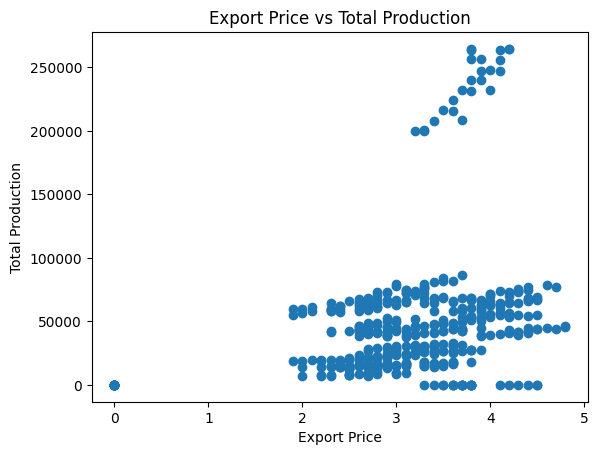

In [41]:
# 19) Relationship between export price and total production
plt.figure()
plt.scatter(df['Export Price'], df['Total Production'])
plt.xlabel("Export Price")
plt.ylabel("Total Production")
plt.title("Export Price vs Total Production")
plt.show()

20) 4–5 Line Summary
• Coffee production varies significantly across countries and years.  
• A few countries contribute the majority of total production.  
• Export price and production show weak/moderate correlation.  
• Some records show domestic consumption exceeding production.  
• Production trend generally increases over years for major producers.